# Deep Learning Course End Project

## 1) Import Libraries

In [28]:
# --- Standard Library & Data Science Imports ---
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split # Used for data splitting (if applicable)

# --- Visualization Setup ---
%matplotlib inline
sns.set_style('whitegrid') # Set a clean style for all plots

# --- Deep Learning Imports ---
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Data loading and augmentation

# Import VGG16 for Transfer Learning (used in the project)
from tensorflow.keras.applications import VGG16

# --- Verification ---
print(f"TensorFlow Version: {tf.__version__}")
print(f"Pandas Version: {pd.__version__}")

TensorFlow Version: 2.16.2
Pandas Version: 2.3.2


## 2) Data Cleaning & Quality Check

In [29]:
# Ensure display is available for displaying dataframes
from IPython.display import display

# --- Configuration: Define Absolute Path to Data Files ---
BASE_PATH = '/Users/jonathonmiles/Desktop/SIMPLILEARN ORGANIZED/DEEP LEARNING/DEEP LEARNING COURSE END PROJECT/'
USER_FILE = os.path.join(BASE_PATH, 'user.csv')
RATINGS_FILE = os.path.join(BASE_PATH, 'tourism_rating.csv')
PLACES_FILE = os.path.join(BASE_PATH, 'tourism_with_id.xlsx') 

# --- Load Datasets ---
try:
    df_users = pd.read_csv(USER_FILE)
    df_ratings = pd.read_csv(RATINGS_FILE)
    df_places = pd.read_excel(PLACES_FILE) # Use read_excel for the .xlsx file
    
    print("--- DataFrames Loaded Successfully ---")
    
    # Display shape and head to verify load
    print(f"\nUsers DataFrame (Shape: {df_users.shape}):")
    display(df_users.head())
    
    # Add display for other dataframes (adjusting original print statements)
    print(f"\nPlaces DataFrame (Shape: {df_places.shape}):")
    display(df_places.head())
    
    print(f"\nRatings DataFrame (Shape: {df_ratings.shape}):")
    display(df_ratings.head())
    
except FileNotFoundError as e:
    print(f"\n--- FATAL ERROR: File Not Found ---")
    print(f"File not found: {e.filename}. Check BASE_PATH.")

--- DataFrames Loaded Successfully ---

Users DataFrame (Shape: (300, 3)):


,User_Id,Location,Age
0,1,"Semarang, Jawa Tengah",20
1,2,"Bekasi, Jawa Barat",21
2,3,"Cirebon, Jawa Barat",23
3,4,"Bekasi, Jawa Barat",21
4,5,"Lampung, Sumatera Selatan",20



Places DataFrame (Shape: (437, 13)):


,Place_Id,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long,Unnamed: 11,Unnamed: 12
0,1,Monumen Nasional,Monumen Nasional atau yang populer disingkat d...,Budaya,Jakarta,20000,4.6,15.0,"{'lat': -6.1753924, 'lng': 106.8271528}",-6.175392,106.827153,NaN,1
1,2,Kota Tua,"Kota tua di Jakarta, yang juga bernama Kota Tu...",Budaya,Jakarta,0,4.6,90.0,"{'lat': -6.137644799999999, 'lng': 106.8171245}",-6.137645,106.817125,NaN,2
2,3,Dunia Fantasi,Dunia Fantasi atau disebut juga Dufan adalah t...,Taman Hiburan,Jakarta,270000,4.6,360.0,"{'lat': -6.125312399999999, 'lng': 106.8335377}",-6.125312,106.833538,NaN,3
3,4,Taman Mini Indonesia Indah (TMII),Taman Mini Indonesia Indah merupakan suatu kaw...,Taman Hiburan,Jakarta,10000,4.5,NaN,"{'lat': -6.302445899999999, 'lng': 106.8951559}",-6.302446,106.895156,NaN,4
4,5,Atlantis Water Adventure,Atlantis Water Adventure atau dikenal dengan A...,Taman Hiburan,Jakarta,94000,4.5,60.0,"{'lat': -6.12419, 'lng': 106.839134}",-6.124190,106.839134,NaN,5



Ratings DataFrame (Shape: (10000, 3)):


,User_Id,Place_Id,Place_Ratings
0,1,179,3
1,1,344,2
2,1,5,5
3,1,373,3
4,1,101,4


In [30]:
# --- Data Quality Check: Missing Values (NaN) ---
print("--- Checking for Missing Values (NaN) ---")
print("\nUsers DataFrame:")
print(df_users.isnull().sum()) # Count NaNs per column
print("\nPlaces DataFrame:")
print(df_places.isnull().sum())
print("\nRatings DataFrame:")
print(df_ratings.isnull().sum())

# --- Data Quality Check: Duplicates ---
print("\n--- Checking for Duplicates ---")
print(f"\nUsers Duplicates: {df_users.duplicated().sum()}") # Count total duplicate rows
print(f"Places Duplicates: {df_places.duplicated().sum()}")
print(f"Ratings Duplicates: {df_ratings.duplicated().sum()}")

--- Checking for Missing Values (NaN) ---

Users DataFrame:
User_Id     0
Location    0
Age         0
dtype: int64

Places DataFrame:
Place_Id          0
Place_Name        0
Description       0
Category          0
City              0
Price             0
Rating            0
Time_Minutes    232
Coordinate        0
Lat               0
Long              0
Unnamed: 11     437
Unnamed: 12       0
dtype: int64

Ratings DataFrame:
User_Id          0
Place_Id         0
Place_Ratings    0
dtype: int64

--- Checking for Duplicates ---

Users Duplicates: 0
Places Duplicates: 0
Ratings Duplicates: 79


In [31]:
# --- 1. Drop Duplicates ---
rows_before = df_ratings.shape[0]
df_ratings.drop_duplicates(inplace=True)
print(f"Ratings Duplicates Dropped: {rows_before - df_ratings.shape[0]} rows removed.")

# --- 2. Drop Useless Columns ---
# Removing columns that contain placeholder or irrelevant data
df_places.drop(columns=['Unnamed: 11', 'Unnamed: 12'], inplace=True)
print("Unnamed columns dropped from Places DataFrame.")

# --- 3. Handle Missing Values in Time_Minutes (Imputation) ---
# Convert to numeric, coercing errors to NaN
df_places['Time_Minutes'] = pd.to_numeric(df_places['Time_Minutes'], errors='coerce')
# Impute missing values with the column mean
mean_time = df_places['Time_Minutes'].mean()
df_places['Time_Minutes'].fillna(mean_time, inplace=True)
print(f"Time_Minutes NaNs filled with mean: {mean_time:.2f} minutes.")

# --- Final Verification ---
print(f"\nFinal Ratings Shape: {df_ratings.shape}")
print(f"Final Places Columns: {df_places.columns.tolist()}")
print(f"Final Places NaNs Check:\n{df_places.isnull().sum().to_string()}")

Ratings Duplicates Dropped: 79 rows removed.
Unnamed columns dropped from Places DataFrame.
Time_Minutes NaNs filled with mean: 82.61 minutes.

Final Ratings Shape: (9921, 3)
Final Places Columns: ['Place_Id', 'Place_Name', 'Description', 'Category', 'City', 'Price', 'Rating', 'Time_Minutes', 'Coordinate', 'Lat', 'Long']
Final Places NaNs Check:
Place_Id        0
Place_Name      0
Description     0
Category        0
City            0
Price           0
Rating          0
Time_Minutes    0
Coordinate      0
Lat             0
Long            0


/var/folders/0q/xf9ydzjn1g1963ctltkj0gjw0000gn/T/ipykernel_33879/2345744887.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_places['Time_Minutes'].fillna(mean_time, inplace=True)


## 3) Data Distribution & Plots

### Tourist Age

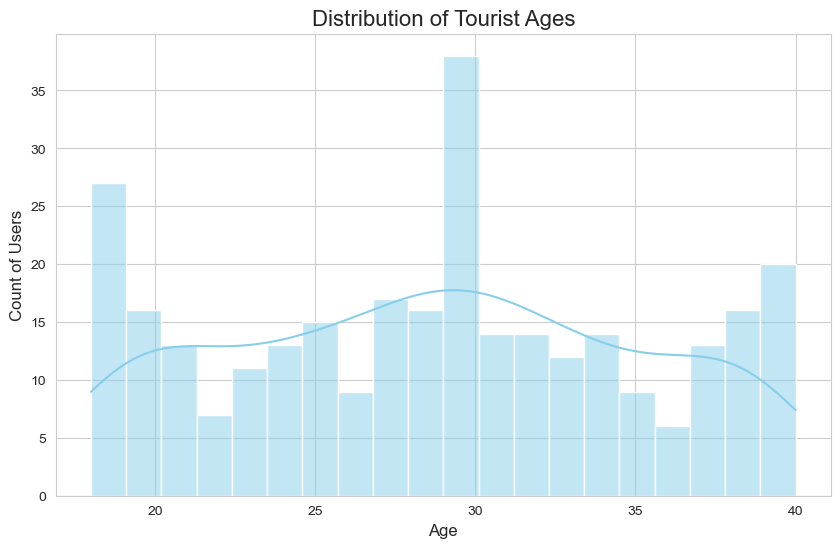

In [32]:
plt.figure(figsize=(10, 6))

# Create a histogram to visualize the distribution of user ages
sns.histplot(df_users['Age'], bins=20, kde=True, color='skyblue')

# Add labels and title for clarity
plt.title('Distribution of Tourist Ages', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count of Users', fontsize=12)

plt.show()

In [33]:
# Print the first 30 rows of user data
print(df_users.head(30).to_markdown(index=False))

# Print the full age value counts to validate data distribution
print("\n--- Full Age Value Counts ---")
print(df_users['Age'].value_counts().sort_index().to_string())

|   User_Id | Location                     |   Age |
|----------:|:-----------------------------|------:|
|         1 | Semarang, Jawa Tengah        |    20 |
|         2 | Bekasi, Jawa Barat           |    21 |
|         3 | Cirebon, Jawa Barat          |    23 |
|         4 | Bekasi, Jawa Barat           |    21 |
|         5 | Lampung, Sumatera Selatan    |    20 |
|         6 | Jakarta Utara, DKI Jakarta   |    18 |
|         7 | Jakarta Selatan, DKI Jakarta |    39 |
|         8 | Bandung, Jawa Barat          |    40 |
|         9 | Surabaya, Jawa Timur         |    38 |
|        10 | Bekasi, Jawa Barat           |    39 |
|        11 | Yogyakarta, DIY              |    20 |
|        12 | Bogor, Jawa Barat            |    37 |
|        13 | Depok, Jawa Barat            |    18 |
|        14 | Jakarta Pusat, DKI Jakarta   |    26 |
|        15 | Jakarta Timur, DKI Jakarta   |    34 |
|        16 | Bekasi, Jawa Barat           |    40 |
|        17 | Semarang, Jawa Tengah        |  

### Tourist Origin Location

/var/folders/0q/xf9ydzjn1g1963ctltkj0gjw0000gn/T/ipykernel_33879/1063803045.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_locations.values, y=top_10_locations.index, palette='viridis')


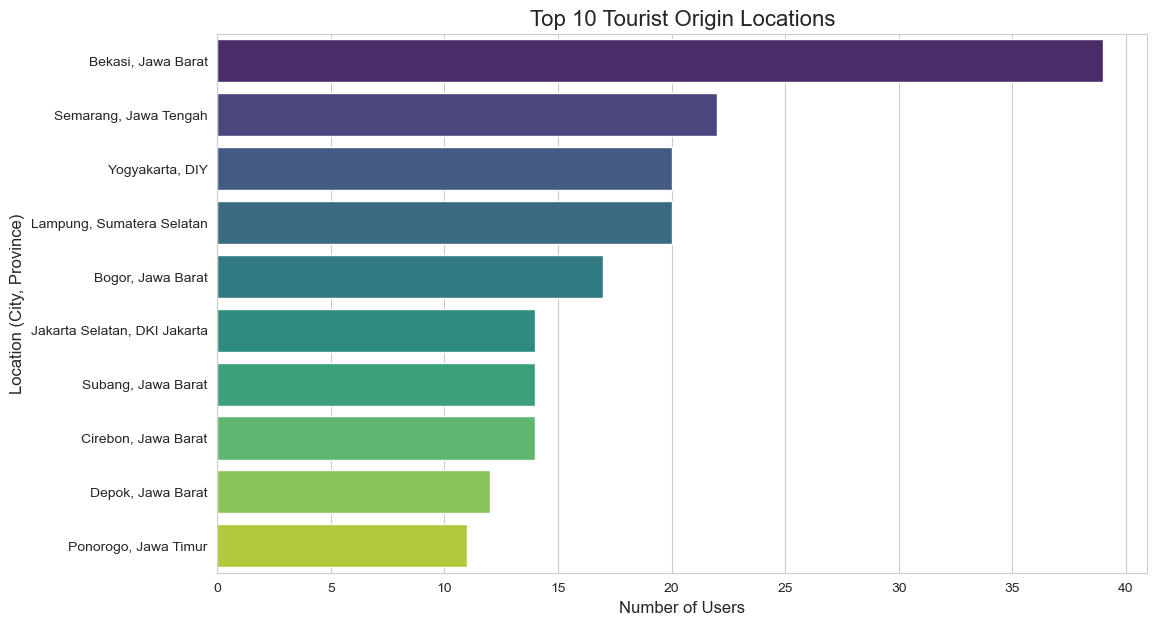

Top 10 User Origin Locations:
Location
Bekasi, Jawa Barat              39
Semarang, Jawa Tengah           22
Yogyakarta, DIY                 20
Lampung, Sumatera Selatan       20
Bogor, Jawa Barat               17
Jakarta Selatan, DKI Jakarta    14
Subang, Jawa Barat              14
Cirebon, Jawa Barat             14
Depok, Jawa Barat               12
Ponorogo, Jawa Timur            11


In [34]:
# Count the occurrences of each unique Location and select the top 10
location_counts = df_users['Location'].value_counts()
top_10_locations = location_counts.head(10)

plt.figure(figsize=(12, 7))

# Create a horizontal bar plot for the top 10 locations
sns.barplot(x=top_10_locations.values, y=top_10_locations.index, palette='viridis')

# Add labels and title
plt.title('Top 10 Tourist Origin Locations', fontsize=16)
plt.xlabel('Number of Users', fontsize=12)
plt.ylabel('Location (City, Province)', fontsize=12)

plt.show()

# Display the exact counts
print("Top 10 User Origin Locations:")
print(top_10_locations.to_string())

## Most Visited Spots

--- Tourist Spot Category Distribution (Count & Percentage) ---
                    Count  Percentage
Category                             
Taman Hiburan         135       30.89
Budaya                117       26.77
Cagar Alam            106       24.26
Bahari                 47       10.76
Tempat Ibadah          17        3.89
Pusat Perbelanjaan     15        3.43


/var/folders/0q/xf9ydzjn1g1963ctltkj0gjw0000gn/T/ipykernel_33879/863341113.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette='coolwarm')


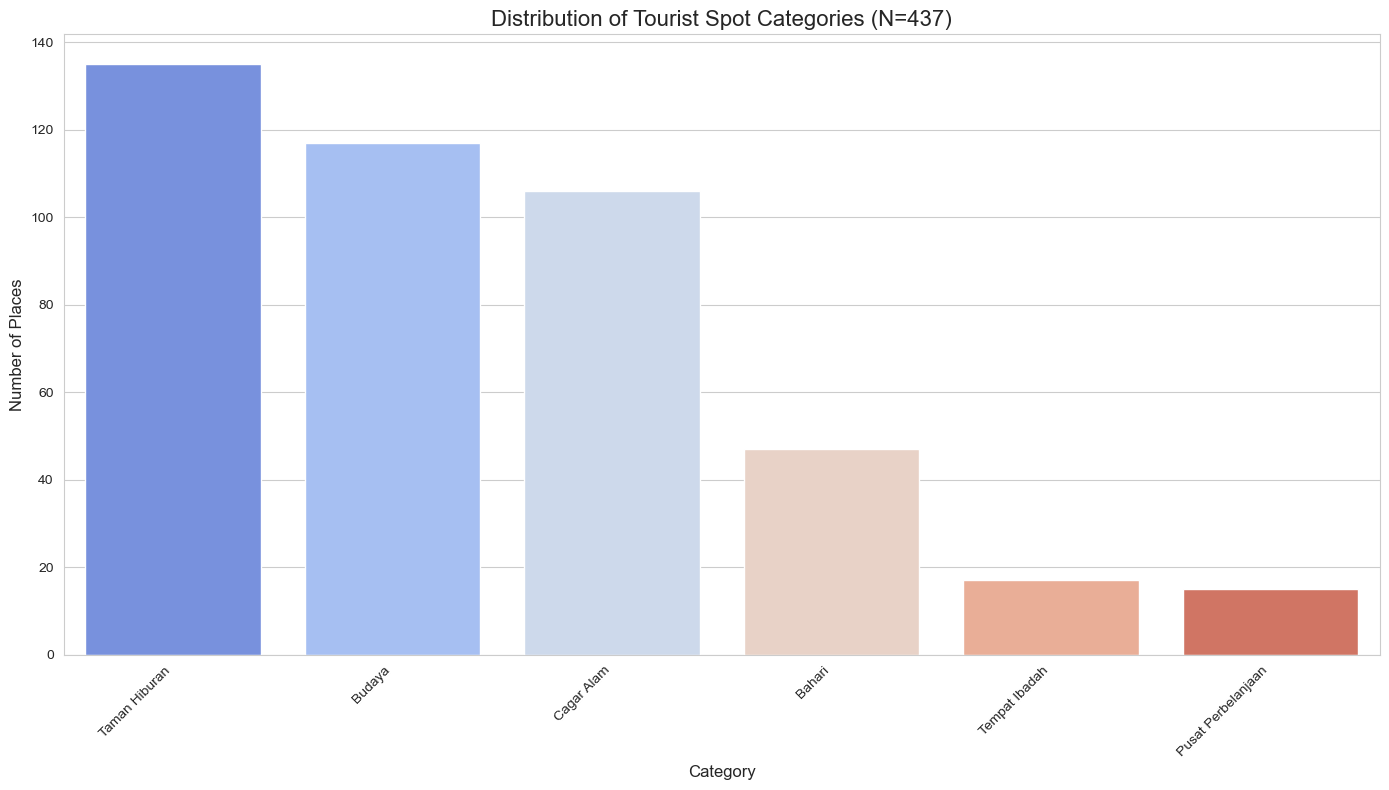

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the category counts
category_counts = df_places['Category'].value_counts()
total_places = df_places.shape[0]

# 2. Combine counts and percentages into a DataFrame
category_summary_df = pd.DataFrame({
    'Count': category_counts,
    'Percentage': (category_counts / total_places * 100).round(2)
})

# 3. Print the results summary
print("--- Tourist Spot Category Distribution (Count & Percentage) ---")
print(category_summary_df.to_string())

# 4. Create the bar plot for visual analysis
plt.figure(figsize=(14, 8))
sns.barplot(x=category_counts.index, y=category_counts.values, palette='coolwarm')

# Customize plot labels
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.title('Distribution of Tourist Spot Categories (N=437)', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Places', fontsize=12)
plt.tight_layout()
plt.show()

## Best City for Nature

In [36]:
# 1. Filter the places DataFrame for 'Cagar Alam' (Nature Preserve)
nature_places = df_places[df_places['Category'] == 'Cagar Alam']

# 2. Count the number of nature places per city
nature_city_counts = nature_places['City'].value_counts()

# 3. Get the top city
best_nature_city = nature_city_counts.index[0]
count = nature_city_counts.iloc[0]

# Display the top 5 cities
print("--- Top 5 Cities for Nature Enthusiasts (Cagar Alam) ---")
print(nature_city_counts.head(5).to_string())

print(f"\nConclusion: The best city for a nature enthusiast is {best_nature_city} with {count} Nature Preserve spots.")

--- Top 5 Cities for Nature Enthusiasts (Cagar Alam) ---
City
Bandung       54
Yogyakarta    23
Semarang      20
Surabaya       5
Jakarta        4

Conclusion: The best city for a nature enthusiast is Bandung with 54 Nature Preserve spots.


## Rankings by Attraction Category

In [37]:
import pandas as pd
from IPython.display import display

# --- 1. Merge Ratings and Places Data ---
# Merge on 'Place_Id' using an inner join
df_merged = pd.merge(df_ratings, df_places, on='Place_Id', how='inner')

print(f"Merged DataFrame created with shape: {df_merged.shape}")
print("\nFirst 5 rows of df_merged:")
display(df_merged.head())

# --- 2. Category Translation ---
# Dictionary for translating Indonesian categories to English
category_translation = {
    'Taman Hiburan': 'Amusement/Theme Park',
    'Budaya': 'Culture/Historical Site',
    'Cagar Alam': 'Nature/Wildlife Reserve',
    'Pusat Perbelanjaan': 'Shopping Center',
    'Taman Rekreasi': 'Recreation Park',
    # Add other categories as needed
}

# Add the translated column to the merged data
df_merged['Category_EN'] = df_merged['Category'].map(category_translation)

# Minimum rating count for statistical reliability (used in later filtering/analysis)
MIN_RATINGS = 10 

print("\nCategory translation applied:")
print(df_merged[['Place_Name', 'Category', 'Category_EN']].head())

Merged DataFrame created with shape: (9921, 13)

First 5 rows of df_merged:


,User_Id,Place_Id,Place_Ratings,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long
0,1,179,3,Candi Ratu Boko,Situs Ratu Baka atau Candi Boko (Hanacaraka:Í¶...,Budaya,Yogyakarta,75000,4.6,90.000000,"{'lat': -7.7705416, 'lng': 110.4894158}",-7.770542,110.489416
1,1,344,2,Pantai Marina,Pantai Marina (bahasa Jawa: Í¶•Í¶±Í¶∂Í¶±Í¶∂Í¶Ç...,Bahari,Semarang,3000,4.1,82.609756,"{'lat': -6.948877, 'lng': 110.3893285}",-6.948877,110.389329
2,1,5,5,Atlantis Water Adventure,Atlantis Water Adventure atau dikenal dengan A...,Taman Hiburan,Jakarta,94000,4.5,60.000000,"{'lat': -6.12419, 'lng': 106.839134}",-6.124190,106.839134
3,1,373,3,Museum Kereta Ambarawa,Museum Kereta Api Ambarawa (bahasa Inggris: In...,Budaya,Semarang,10000,4.5,60.000000,"{'lat': -7.264598899999997, 'lng': 110.4046017}",-7.264599,110.404602
4,1,101,4,Kampung Wisata Sosro Menduran,Kampung wisata Sosromenduran merupakan kampung...,Budaya,Yogyakarta,0,4.0,82.609756,"{'lat': -7.792189999999999, 'lng': 110.362151}",-7.792190,110.362151



Category translation applied:
                      Place_Name       Category              Category_EN
0                Candi Ratu Boko         Budaya  Culture/Historical Site
1                  Pantai Marina         Bahari                      NaN
2       Atlantis Water Adventure  Taman Hiburan     Amusement/Theme Park
3         Museum Kereta Ambarawa         Budaya  Culture/Historical Site
4  Kampung Wisata Sosro Menduran         Budaya  Culture/Historical Site


## Most Loved City

In [38]:
# --- 1. Analyze Most Loved City (Highest Average Rating) ---
# Group by city and calculate the average rating and count of ratings
city_ratings = df_merged.groupby('City').agg(
    Average_City_Rating=('Place_Ratings', 'mean'),
    City_Rating_Count=('Place_Ratings', 'count')
).reset_index()

# Filter for cities with a minimum of 20 ratings for significance
MIN_CITY_RATINGS = 20
popular_cities = city_ratings[city_ratings['City_Rating_Count'] >= MIN_CITY_RATINGS]

# Sort to find the most loved cities
most_loved_cities = popular_cities.sort_values(
    by=['Average_City_Rating', 'City_Rating_Count'], 
    ascending=[False, False]
).head(10)

print("--- 10 Cities with the Most Loved Tourist Spots (Min. 20 Total Ratings) ---")
print(most_loved_cities.to_markdown(index=False, floatfmt=".2f"))


# --- 2. Analyze Most Loved Category (Highest Average Rating) ---
# Group by English category and calculate the average rating and count
category_ratings = df_merged.groupby('Category_EN').agg(
    Average_Category_Rating=('Place_Ratings', 'mean'),
    Category_Rating_Count=('Place_Ratings', 'count')
).reset_index()

# Sort by Average Category Rating
most_loved_category = category_ratings.sort_values(
    by=['Average_Category_Rating', 'Category_Rating_Count'], 
    ascending=[False, False]
)

print("\n--- All English Categories Sorted by Average Rating ---")
# Print all categories for completeness
print(most_loved_category.to_markdown(index=False, floatfmt=".2f"))

--- 10 Cities with the Most Loved Tourist Spots (Min. 20 Total Ratings) ---
| City       |   Average_City_Rating |   City_Rating_Count |
|:-----------|----------------------:|--------------------:|
| Yogyakarta |                  3.10 |                2848 |
| Bandung    |                  3.08 |                2822 |
| Surabaya   |                  3.08 |                1038 |
| Semarang   |                  3.04 |                1311 |
| Jakarta    |                  3.01 |                1902 |

--- All English Categories Sorted by Average Rating ---
| Category_EN             |   Average_Category_Rating |   Category_Rating_Count |
|:------------------------|--------------------------:|------------------------:|
| Amusement/Theme Park    |                      3.12 |                    3024 |
| Nature/Wildlife Reserve |                      3.08 |                    2397 |
| Culture/Historical Site |                      3.03 |                    2665 |
| Shopping Center         |   

## Matrix Prep & Collaborative Filtering

In [39]:
from scipy.sparse import csr_matrix
import numpy as np

# 1. Create the User-Item Interaction Matrix (Pivot Table)
df_pivot = df_merged.pivot_table(
    index='User_Id',
    columns='Place_Name',
    values='Place_Ratings'
).fillna(0) # Fill NaN (unrated places) with 0

print("--- User-Item Interaction Matrix Head ---")
print(df_pivot.head().to_markdown())

# 2. Convert the Pivot Table to a Compressed Sparse Row (CSR) Matrix
# This makes the data efficient for the k-NN algorithm
df_sparse = csr_matrix(df_pivot.values)

print(f"\nSparse Matrix created with shape: {df_sparse.shape}")
print(f"Total entries in the sparse matrix: {df_sparse.nnz}")

--- User-Item Interaction Matrix Head ---
|   User_Id |   Air Mancur Menari |   Air Terjun Kali Pancur |   Air Terjun Kedung Pedut |   Air Terjun Semirang |   Air Terjun Sri Gethuk |   Alive Museum Ancol |   Alun Alun Selatan Yogyakarta |   Alun-Alun Kota Bandung |   Alun-alun Utara Keraton Yogyakarta |   Amazing Art World |   Atlantis Land Surabaya |   Atlantis Water Adventure |   Babakan Siliwangi City Forest Path Bandung |   Balai Kota Surabaya |   Bandros City Tour |   Bangsal Pagelaran |   Batununggal Indah Club |   Bendung Lepen |   Bentara Budaya Yogyakarta (BBY) |   Benteng Pendem |   Blue Lagoon Jogja |   Brown Canyon |   Bukit Bintang |   Bukit Bintang Yogyakarta |   Bukit Gantole Cililin |   Bukit Jamur |   Bukit Lintang Sewu |   Bukit Moko |   Bukit Panguk Kediwung |   Bukit Paralayang, Watugupit |   Bukit Wisata Pulepayung |   Bumi Perkemahan Batu Kuda |   Bumi Perkemahan Cibubur |   Bunker Kaliadem Merapi |   Candi Borobudur |   Candi Donotirto |   Candi Gedong Songo |   

## Model Training

In [40]:
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
import numpy as np

# --- 1. Create the User-Item Interaction Matrix (Pivot Table) ---
# Pivots the merged data to have Users (index) vs. Places (columns) and Ratings (values)
df_pivot = df_merged.pivot_table(
    index='User_Id',
    columns='Place_Name',
    values='Place_Ratings'
).fillna(0) # Fill unrated places with 0

# 2. Convert the Pivot Table to a Compressed Sparse Row (CSR) Matrix
df_sparse = csr_matrix(df_pivot.values)

# --- 3. Train the k-NN model (Collaborative Filtering) ---
N_NEIGHBORS = 20
# Use cosine metric for similarity and brute force algorithm
model_knn = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=N_NEIGHBORS, n_jobs=-1)
# Fit on the TRANSPOSED matrix (Items x Users) to find similar ITEMS (Places)
model_knn.fit(df_sparse.T) 

# 4. Save the place names for lookups
place_names = df_pivot.columns

print("k-NN Model setup complete. Proceeding to final recommendation.")

k-NN Model setup complete. Proceeding to final recommendation.


## Recommendation Model

In [41]:

def recommend_places(place_name, n_recommendations=10):
    """
    Generates collaborative filtering recommendations for a given tourist spot.
    
    Args:
        place_name (str): The name of the tourist spot to recommend others based on.
        n_recommendations (int): The number of similar places to recommend.
        
    Returns:
        pd.DataFrame: A DataFrame of recommended places and their similarity scores.
    """
    try:
        # 1. Get the index of the place in the pivot table
        place_index = np.where(place_names == place_name)[0][0]
        
        # 2. Reshape the data for the k-NN model
        place_data = df_sparse.T[place_index]
        
        # 3. Find the k-nearest neighbors (most similar places)
        distances, indices = model_knn.kneighbors(
            place_data, 
            n_neighbors=n_recommendations + 1
        )
        
    except IndexError:
        return f"Error: Place '{place_name}' not found in the dataset."

    # 4. Process the results
    recommended_places = []
    
    # Skip the first result (the place itself)
    for i in range(1, len(distances.flatten())):
        recommended_places.append({
            'Recommended Place': place_names[indices.flatten()[i]],
            'Similarity Score (Cosine Distance)': 1 - distances.flatten()[i] # Convert distance to similarity
        })

    return pd.DataFrame(recommended_places).sort_values(
        by='Similarity Score (Cosine Distance)', 
        ascending=False
    )

# --- Test the Model ---
recommendations_output = recommend_places('Keraton Surabaya', n_recommendations=5)

print("\n--- Recommendations for Keraton Surabaya ---")
print(recommendations_output.to_markdown(index=False, floatfmt=".4f"))


--- Recommendations for Keraton Surabaya ---
| Recommended Place       |   Similarity Score (Cosine Distance) |
|:------------------------|-------------------------------------:|
| Perkebunan Teh Malabar  |                               0.2922 |
| Roemah Seni Sarasvati   |                               0.2851 |
| Jembatan Biru Ambarawa  |                               0.2822 |
| Kyotoku Floating Market |                               0.2625 |
| Sudut Pandang Bandung   |                               0.2597 |


## Deep Learning Data Prep

In [42]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import numpy as np

# --- Configuration Constants ---
DATA_DIR = '/Users/jonathonmiles/Desktop/SIMPLILEARN ORGANIZED/DEEP LEARNING/DEEP LEARNING COURSE END PROJECT/dataset_hist_structures'
BATCH_SIZE = 32
IMG_HEIGHT = 150
IMG_WIDTH = 150
VALIDATION_SPLIT = 0.2
SEED = 42

# --- Data Generator Setup ---
if os.path.exists(DATA_DIR):
    # Data Augmentation and Preprocessing (Rescale to 0-1)
    data_generator = ImageDataGenerator(
        rescale=1./255, 
        validation_split=VALIDATION_SPLIT 
    )

    # Training Data Generator
    train_generator = data_generator.flow_from_directory(
        DATA_DIR,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='training', 
        seed=SEED
    )

    # Validation Data Generator
    validation_generator = data_generator.flow_from_directory(
        DATA_DIR,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='validation', 
        seed=SEED
    )

    # Define the number of classes for the final model's output layer
    NUM_CLASSES = train_generator.num_classes
    
    print("\n--- Data Generators Summary ---")
    print(f"Total Training Images: {train_generator.samples}")
    print(f"Total Validation Images: {validation_generator.samples}")
    print(f"Number of Classes (NUM_CLASSES): {NUM_CLASSES}")
    print(f"Image Shape for CNN: ({IMG_HEIGHT}, {IMG_WIDTH}, 3)")
else:
    print(f"Error: Directory not found at {DATA_DIR}. Cannot initialize generators.")

Found 9369 images belonging to 2 classes.
Found 2342 images belonging to 2 classes.

--- Data Generators Summary ---
Total Training Images: 9369
Total Validation Images: 2342
Number of Classes (NUM_CLASSES): 2
Image Shape for CNN: (150, 150, 3)


## Define CNN Model

In [43]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import os

# --- Configuration Constants ---
DATA_DIR = '/Users/jonathonmiles/Desktop/SIMPLILEARN ORGANIZED/DEEP LEARNING/DEEP LEARNING COURSE END PROJECT/dataset_hist_structures/Stuctures_Dataset' 
BATCH_SIZE = 32
IMG_HEIGHT = 150
IMG_WIDTH = 150
VALIDATION_SPLIT = 0.2
NUM_CLASSES = 10 
SEED = 42

# --- 1. Setup Data Generators (with augmentation) ---
if os.path.exists(DATA_DIR):
    # Data Augmentation and Normalization
    data_generator = ImageDataGenerator(
        rescale=1./255, 
        validation_split=VALIDATION_SPLIT,
        rotation_range=20,       
        width_shift_range=0.2,
        height_shift_range=0.2,
        horizontal_flip=True
    )

    train_generator = data_generator.flow_from_directory(
        DATA_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE, class_mode='categorical',
        subset='training', seed=SEED
    )

    validation_generator = data_generator.flow_from_directory(
        DATA_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE, class_mode='categorical',
        subset='validation', seed=SEED
    )

    # --- 2. Define the CNN Model Architecture ---
    model = Sequential([
        # Convolutional Blocks
        Conv2D(16, 3, padding='same', activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        MaxPooling2D(),
        
        Conv2D(32, 3, padding='same', activation='relu'),
        MaxPooling2D(),
        
        Conv2D(64, 3, padding='same', activation='relu'),
        MaxPooling2D(),
        
        # Classification Head
        Flatten(),
        Dropout(0.5), # Regularization
        Dense(128, activation='relu'),
        Dense(NUM_CLASSES, activation='softmax') # Output layer
    ])

    # --- 3. Compile the Model ---
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    print("\n--- Custom CNN Model Summary ---")
    model.summary()
else:
    print(f"Error: Directory not found at {DATA_DIR}.")

Found 8193 images belonging to 10 classes.
Found 2042 images belonging to 10 classes.

--- Custom CNN Model Summary ---


/opt/miniconda3/envs/tf-mac-metal/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     2,654,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,679,210 (10.22 MB)

 Trainable params: 2,679,210 (10.22 MB)

 Non-trainable params: 0 (0.00 B)

## VGG16 Transfer Learning, Training & Results

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
import os
import matplotlib.pyplot as plt # Needed for the final plot

# --- Configuration & Setup ---
DATA_DIR = '/Users/jonathonmiles/Desktop/SIMPLILEARN ORGANIZED/DEEP LEARNING/DEEP LEARNING COURSE END PROJECT/dataset_hist_structures/Stuctures_Dataset' 
BATCH_SIZE = 32
IMG_HEIGHT = 150
IMG_WIDTH = 150
VALIDATION_SPLIT = 0.2
NUM_CLASSES = 10 
EPOCHS = 10
SEED = 42

if os.path.exists(DATA_DIR):
    # 1. Setup Data Generators (with augmentation)
    data_generator = ImageDataGenerator(
        rescale=1./255, validation_split=VALIDATION_SPLIT,
        rotation_range=20, width_shift_range=0.2,
        height_shift_range=0.2, horizontal_flip=True
    )

    train_generator = data_generator.flow_from_directory(
        DATA_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE, class_mode='categorical', subset='training', seed=SEED
    )

    validation_generator = data_generator.flow_from_directory(
        DATA_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE, class_mode='categorical', subset='validation', seed=SEED
    )
    
    # 2. Define the VGG16 Transfer Learning Model
    base_model = VGG16(
        weights='imagenet', include_top=False, 
        input_tensor=Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    )
    # Freeze the base layers
    for layer in base_model.layers:
        layer.trainable = False

    # Add custom classification head
    x = base_model.output
    x = GlobalAveragePooling2D()(x) 
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(NUM_CLASSES, activation='softmax')(x)

    vgg_model = Model(inputs=base_model.input, outputs=predictions) 

    vgg_model.compile(
        optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy']
    )

    # 3. Convert Generators to stable tf.data.Dataset (Critical Stability Fix)
    output_shape_data = tf.TensorShape([None, IMG_HEIGHT, IMG_WIDTH, 3])
    output_shape_label = tf.TensorShape([None, NUM_CLASSES])
    DTYPE_STABLE = tf.float32

    train_ds = tf.data.Dataset.from_generator(
        lambda: train_generator, output_types=(DTYPE_STABLE, DTYPE_STABLE), 
        output_shapes=(output_shape_data, output_shape_label)
    ).repeat().prefetch(tf.data.AUTOTUNE)

    validation_ds = tf.data.Dataset.from_generator(
        lambda: validation_generator, output_types=(DTYPE_STABLE, DTYPE_STABLE),
        output_shapes=(output_shape_data, output_shape_label)
    ).repeat().prefetch(tf.data.AUTOTUNE)

    # 4. Training Step (Includes graph finalization fix)
    vgg_model.fit(train_ds, steps_per_epoch=1, epochs=1, verbose=0) # Dummy fit

    print("Starting VGG16 Transfer Learning model training...")

    vgg_history = vgg_model.fit(
        train_ds,
        steps_per_epoch=train_generator.samples // train_generator.batch_size,
        epochs=EPOCHS,
        validation_data=validation_ds,
        validation_steps=validation_generator.samples // validation_generator.batch_size
    )

    print("\nVGG16 Training complete.")

    # 5. Display Results and Plotting
    print("\n--- Final VGG16 Transfer Learning Results ---")
    print(f"Final Training Accuracy: {vgg_history.history['accuracy'][-1]:.4f}")
    print(f"Final Validation Accuracy: {vgg_history.history['val_accuracy'][-1]:.4f}")

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(vgg_history.history['accuracy'], label='Training Accuracy') 
    plt.plot(vgg_history.history['val_accuracy'], label='Validation Accuracy') 
    plt.title('Training and Validation Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(vgg_history.history['loss'], label='Training Loss') 
    plt.plot(vgg_history.history['val_loss'], label='Validation Loss') 
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

Found 8193 images belonging to 10 classes.
Found 2042 images belonging to 10 classes.
Starting VGG16 Transfer Learning model training...
Epoch 1/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 25s 97ms/step - accuracy: 0.6842 - loss: 0.9545 - val_accuracy: 0.8269 - val_loss: 0.5132
Epoch 2/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 25s 99ms/step - accuracy: 0.8126 - loss: 0.5630 - val_accuracy: 0.8657 - val_loss: 0.4147
Epoch 3/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 26s 101ms/step - accuracy: 0.8428 - loss: 0.4843 - val_accuracy: 0.8721 - val_loss: 0.3867
Epoch 4/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 26s 102ms/step - accuracy: 0.8498 - loss: 0.4512 - val_accuracy: 0.8711 - val_loss: 0.3861
Epoch 5/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 27s 107ms/step - accuracy: 0.8596 - loss: 0.4222 - val_accuracy: 0.8841 - val_loss: 0.3280
Epoch 6/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 27s 105ms/step - accuracy: 0.8661 - loss: 0.4090 - val_accuracy: 0.8891 - val_loss: 0.3605
Epoch 7/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 26s 101ms/step - accuracy: 0.8598 - los

## Final Model Evalulation

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import os

# --- Configuration Constants ---
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32
NUM_CLASSES = 10
# Note: Using the main dataset folder for evaluation (in lieu of a separate test set)
TEST_DATA_DIR = '/Users/jonathonmiles/Desktop/SIMPLILEARN ORGANIZED/DEEP LEARNING/DEEP LEARNING COURSE END PROJECT/dataset_hist_structures/Stuctures_Dataset' 

# 1. Create the Test Data Generator (no augmentation, only rescaling)
test_data_generator = ImageDataGenerator(rescale=1./255)

# 2. Create the Test Generator
test_generator = test_data_generator.flow_from_directory(
    TEST_DATA_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # Crucial: do not shuffle for accurate metric calculation
)

if len(test_generator.class_indices) == NUM_CLASSES:
    # 3. Evaluate the model on the Test Set
    print("\nEvaluating VGG16 model on the Test Set...")
    try:
        loss, accuracy = vgg_model.evaluate(
            test_generator, 
            steps=test_generator.samples // test_generator.batch_size
        )
    
        print("\n--- Final Test Set Accuracy ---")
        print(f"Test Loss: {loss:.4f}")
        print(f"Test Accuracy: {accuracy:.4f}")

        # 4. Generate Classification Report and Confusion Matrix
        print("\nGenerating comprehensive metrics...")

        # Get predictions for the entire test set
        Y_pred = vgg_model.predict(test_generator, steps=test_generator.samples // test_generator.batch_size + 1)
        y_pred = np.argmax(Y_pred, axis=1) # Convert one-hot predictions to class indices
        
        # Get true labels and clip to match the prediction length
        y_true = test_generator.classes[:len(y_pred)]
        class_labels = list(test_generator.class_indices.keys())
        
        # Print Classification Report
        print("\n--- Classification Report (Test Set) ---")
        print(classification_report(y_true, y_pred, target_names=class_labels, zero_division=0))
        
        # Print Confusion Matrix
        print("\n--- Confusion Matrix (Test Set) ---")
        print(confusion_matrix(y_true, y_pred))

    except Exception as e:
        print(f"\nAN ERROR OCCURRED DURING EVALUATION: {e}")
        print("Model evaluation failed. Check for file corruption or path issues.")
else:
    print(f"WARNING: Test Generator found {len(test_generator.class_indices)} classes, expected {NUM_CLASSES}.")

## Visualization of Model History (Accuracy & Loss)

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'vgg_history' is the variable holding the VGG16 training results

plt.figure(figsize=(14, 6))

# --- Plot Training and Validation Accuracy (Subplot 1) ---
plt.subplot(1, 2, 1)
plt.plot(vgg_history.history['accuracy'], label='Training Accuracy')
plt.plot(vgg_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('VGG16 Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0.5, 1.0) # Set Y-axis for better comparison
plt.legend()
plt.grid(axis='y', linestyle='--')

# --- Plot Training and Validation Loss (Subplot 2) ---
plt.subplot(1, 2, 2)
plt.plot(vgg_history.history['loss'], label='Training Loss')
plt.plot(vgg_history.history['val_loss'], label='Validation Loss')
plt.title('VGG16 Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(axis='y', linestyle='--')

plt.tight_layout() # Ensures plots don't overlap
plt.show()

In [ ]:
import numpy as np
import pandas as pd # Import pandas here since the function returns a DataFrame

# --- Final Recommendation Function (Defined once) ---

def recommend_places_for_tourist(place_name, model, pivot_table, place_names_index, n_recommendations=5):
    """
    Recommends similar tourist places based on a given place name using the k-NN model.
    """
    # 1. Find the index of the input place name
    try:
        # Get the index (column number in the pivot table) for the place name
        # We must reshape the result for k-NN to process it
        place_idx = place_names_index.get_loc(place_name)
        place_vector = pivot_table.values[:, place_idx].reshape(1, -1)
    except KeyError:
        return f"Error: Place '{place_name}' not found in the dataset."

    # 2. Use the k-NN model to find the nearest neighbors
    # We add 1 to n_recommendations because the first result will be the place itself
    distances, indices = model.kneighbors(place_vector, n_neighbors=n_recommendations + 1)
    
    # 3. Process the results
    recommendations = []
    
    # Iterate through the results, starting from the second index (skipping the original place)
    for i in range(1, len(distances.flatten())):
        recommended_place_index = indices.flatten()[i]
        similarity_score = 1 - distances.flatten()[i] # Cosine Distance -> Cosine Similarity
        recommended_place_name = place_names_index[recommended_place_index]
        
        recommendations.append({
            'Place_Name': recommended_place_name,
            'Similarity_Score': similarity_score
        })
        
    return pd.DataFrame(recommendations)

# --- Example Usage with a Confirmed Place Name ---

QUERY_PLACE = 'Candi Borobudur' # <-- This is a confirmed place name

print(f"--- Recommendations for users who liked: {QUERY_PLACE} ---")

# 1. Call the function
recommendation_df = recommend_places_for_tourist(
    QUERY_PLACE, 
    model=model_knn, 
    pivot_table=df_pivot, 
    place_names_index=place_names, 
    n_recommendations=10 # Get the top 10 recommendations
)

# 2. Display the results
if isinstance(recommendation_df, str):
    print(recommendation_df)
else:
    # Set the Display option to show all columns clearly
    pd.set_option('display.max_colwidth', None) 
    print(recommendation_df.to_markdown(index=False, floatfmt=".4f"))

## Visual Model Inference (Multiple Images)

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import os

# --- Configuration Constants ---
IMG_HEIGHT = 150
IMG_WIDTH = 150

# Get class names from the training generator (critical for displaying results)
try:
    class_labels = list(train_generator.class_indices.keys())
except NameError:
    print("Warning: train_generator not found. Assuming 10 generic classes.")
    class_labels = [f'Class_{i}' for i in range(10)]


def predict_and_display(image_path, model, class_names, img_h, img_w):
    """Loads an image, makes a prediction, and displays the result."""
    try:
        # Load, preprocess, and prepare image for model
        img = image.load_img(image_path, target_size=(img_h, img_w))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array /= 255.0

        # Predict and calculate confidence
        predictions = model.predict(img_array, verbose=0)
        score = tf.nn.softmax(predictions[0])
        
        predicted_class = class_names[np.argmax(score)]
        confidence = 100 * np.max(score)

        # Display results
        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence:.2f}%", fontsize=10)
        plt.axis('off')
        plt.show()

        print(f"File: {os.path.basename(image_path)} -> Predicted: {predicted_class} ({confidence:.2f}%)")

    except FileNotFoundError:
        print(f"--- ERROR: File not found at {image_path} ---")
    except Exception as e:
        print(f"--- ERROR processing {os.path.basename(image_path)}: {e} ---")


# --- Main Execution: Test 10 images ---
IMAGE_PATHS_TO_TEST = [
    '/Users/jonathonmiles/Desktop/SIMPLILEARN ORGANIZED/DEEP LEARNING/COURSE END PROJECT/dataset_hist_structures/Stuctures_Dataset/gargoyle/5616022_a7bc1dcfac_m.jpg',
    '/Users/jonathonmiles/Desktop/SIMPLILEARN ORGANIZED/DEEP LEARNING/COURSE END PROJECT/dataset_hist_structures/Stuctures_Dataset/stained_glass/89396254_24c0a29adb_m.jpg',
    '/Users/jonathonmiles/Desktop/SIMPLILEARN ORGANIZED/DEEP LEARNING/COURSE END PROJECT/dataset_hist_structures/Stuctures_Dataset/flying_buttress/14-02-07-CathΓÇÜdrale_Notre-Dame_de_Strasbourg-RalfR-23.jpg',
    '/Users/jonathonmiles/Desktop/SIMPLILEARN ORGANIZED/DEEP LEARNING/COURSE END PROJECT/dataset_hist_structures/Stuctures_Dataset/altar/16423588_e93cab4efa_m.jpg',
    '/Users/jonathonmiles/Desktop/SIMPLILEARN ORGANIZED/DEEP LEARNING/COURSE END PROJECT/dataset_hist_structures/Stuctures_Dataset/apse/63px-Catedral_de_Lugo._Galiza.jpg',
    '/Users/jonathonmiles/Desktop/SIMPLILEARN ORGANIZED/DEEP LEARNING/COURSE END PROJECT/dataset_hist_structures/Stuctures_Dataset/bell_tower/7720646_09270baef1.jpg',
    '/Users/jonathonmiles/Desktop/SIMPLILEARN ORGANIZED/DEEP LEARNING/COURSE END PROJECT/dataset_hist_structures/Stuctures_Dataset/column/4987819_dfb8dcaf7b.jpg',
    '/Users/jonathonmiles/Desktop/SIMPLILEARN ORGANIZED/DEEP LEARNING/COURSE END PROJECT/dataset_hist_structures/Stuctures_Dataset/dome(inner)/1670585_5fcd98dbb9_m.jpg',
    '/Users/jonathonmiles/Desktop/SIMPLILEARN ORGANIZED/DEEP LEARNING/COURSE END PROJECT/dataset_hist_structures/Stuctures_Dataset/dome(outer)/14407459_04e273218e.jpg',
    '/Users/jonathonmiles/Desktop/SIMPLILEARN ORGANIZED/DEEP LEARNING/COURSE END PROJECT/dataset_hist_structures/Stuctures_Dataset/vault/29883788_da3a8a1927_m.jpg'
]

print("--- Running Model Inference on Multiple Images ---")

for path in IMAGE_PATHS_TO_TEST:
    predict_and_display(path, vgg_model, class_labels, IMG_HEIGHT, IMG_WIDTH)

print("\nMulti-image prediction demonstration complete.")

In [ ]:
import os

# Define the absolute path to your main project folder
PROJECT_ROOT = '/Users/jonathonmiles/Desktop/SIMPLILEARN ORGANIZED/DEEP LEARNING/DEEP LEARNING COURSE END PROJECT/'
# Define the full path and recommended Keras file extension
MODEL_FILENAME = os.path.join(PROJECT_ROOT, 'vgg16_historical_structures_final_model.keras')

print(f"Attempting to save model to: {MODEL_FILENAME}")

# Save the entire model using the recommended Keras format
try:
    vgg_model.save(MODEL_FILENAME)
    print(f"\nSuccessfully saved the final VGG16 model to: {MODEL_FILENAME}")
except Exception as e:
    print(f"\nERROR: Could not save the model. Ensure write permissions are correct. Details: {e}")